<a href="https://colab.research.google.com/github/zainabsajid247-collab/Pneumonia-Detection-CNN/blob/main/pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os

# 1. Create the folder
if not os.path.exists('/content/my_data'):
    os.makedirs('/content/my_data')

# 2. Unzip the first file from Drive
print("Unzipping the first file...")
!unzip -qo "/content/drive/MyDrive/archive (3).zip" -d "/content/my_data"

# 3. Unzip the second file (archive (2).zip) which is inside 'my_data'
print("Unzipping the inner file...")
!unzip -qo "/content/my_data/archive (2).zip" -d "/content/my_data"

# 4. Final check - you should see 'chest_xray' or 'train' folders now
print("Final folders inside my_data:", os.listdir("/content/my_data"))

Unzipping the first file...
Unzipping the inner file...
Final folders inside my_data: ['archive (2).zip', 'chest_xray']


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
base_path = '/content/my_data/chest_xray/'
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)
print("Attempting to load training images...")
train_generator = train_datagen.flow_from_directory(
    base_path + 'train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)
print("Attempting to load test images...")
validation_generator = test_datagen.flow_from_directory(
    base_path + 'test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Attempting to load training images...
Found 5216 images belonging to 2 classes.
Attempting to load test images...
Found 624 images belonging to 2 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Creating a Sequential model with multiple layers
model = Sequential([
    # Layer 1: Detects basic patterns
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    # Layer 2: Detects more complex shapes
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    # Layer 3: Extracts high-level features
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    # Neural Network layers
    Dense(512, activation='relu'),
    Dropout(0.5), # Prevents overfitting (memorization)
    # Final output (Sigmoid for binary classification)
    Dense(1, activation='sigmoid')
])
# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Model architecture built successfully!")
model.summary()

Model architecture built successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
]
history = model.fit(
    train_generator,
    steps_per_epoch=163,epochs=12,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=callbacks_list
)
print("Training with better accuracy completed!")

Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 477ms/step - accuracy: 0.8252 - loss: 0.4105 - val_accuracy: 0.7933 - val_loss: 0.5294
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.8959 - loss: 0.2524 - val_accuracy: 0.8237 - val_loss: 0.4942
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 468ms/step - accuracy: 0.9101 - loss: 0.2215 - val_accuracy: 0.8638 - val_loss: 0.3746
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 472ms/step - accuracy: 0.9172 - loss: 0.2006 - val_accuracy: 0.8013 - val_loss: 0.5157
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 482ms/step - accuracy: 0.9245 - loss: 0.1873 - val_accuracy: 0.8958 - val_loss: 0.3432
Epoch 6/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 471ms/step - accuracy: 0.9289 - loss: 0.1772 - val_accuracy: 0.7548 - val_loss: 0.7916
Epoch 7/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.9387 - loss: 0.1513 - val_accuracy: 0.8654 - val_loss: 0.4358
Epoch 8/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.9440 - loss: 0

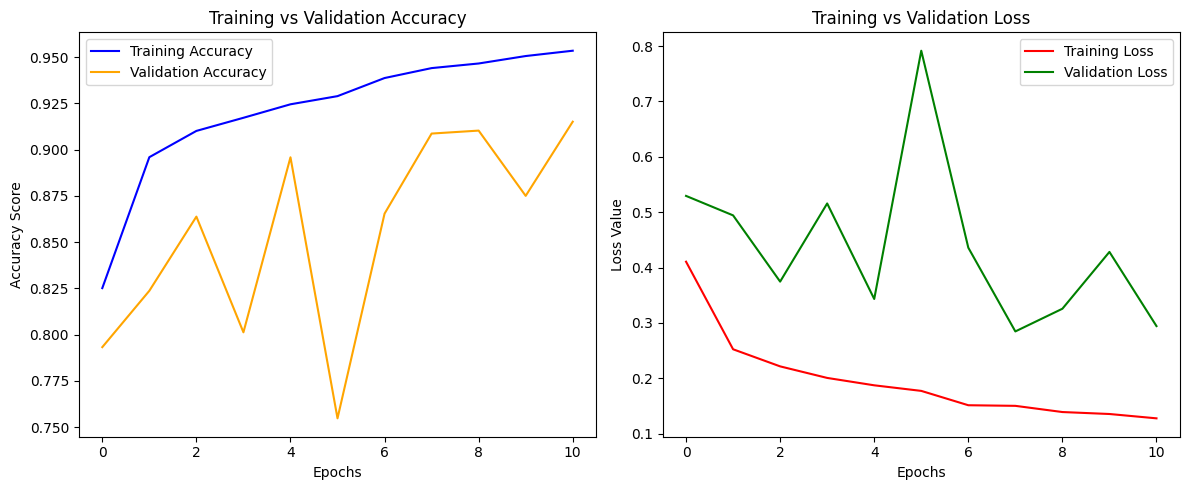

In [13]:
import matplotlib.pyplot as plt
# 1. Create a figure to hold the graphs
plt.figure(figsize=(12, 5))
# 2. Subplot 1: Accuracy Graph
plt.subplot(1, 2, 1) # (rows, columns, index)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend()
# 3. Subplot 2: Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
# 4. Show the plots
plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step


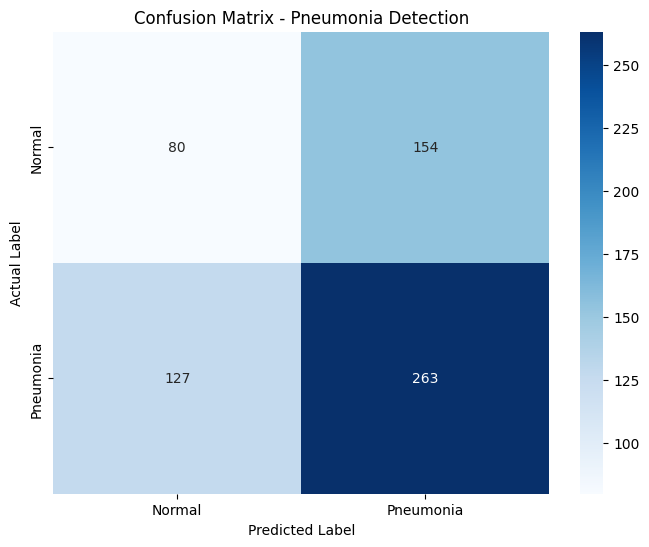


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.39      0.34      0.36       234
   Pneumonia       0.63      0.67      0.65       390

    accuracy                           0.55       624
   macro avg       0.51      0.51      0.51       624
weighted avg       0.54      0.55      0.54       624



In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
validation_generator.reset()
predictions = model.predict(validation_generator, steps=len(validation_generator))
predicted_classes = np.where(predictions > 0.5, 1, 0)
# 4. Get the true labels from the generator
true_classes = validation_generator.classes
# 5. Create the Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
# 6. Plot the Confusion Matrix using Seaborn for better visuals
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix - Pneumonia Detection')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
# 7. Print the Detailed Report (Precision, Recall, F1-Score)
print("\nDetailed Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

Saving person3_bacteria_13.jpeg to person3_bacteria_13.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


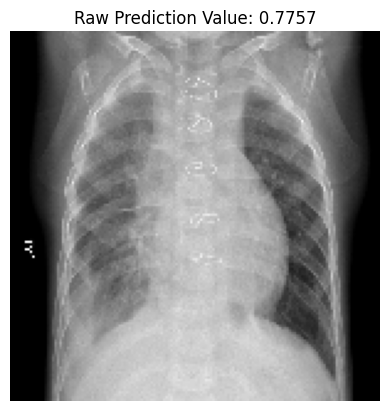

CONCLUSION: PNEUMONIA DETECTED
Probability: 77.57%


In [15]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
# 1. Upload Test Image
uploaded = files.upload()
for fn in uploaded.keys():
    path = '/content/' + fn
    img = image.load_img(path, target_size=(150, 150))
    # Preprocessing
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0
    # Prediction
    prediction = model.predict(x)
    # Plotting
    plt.imshow(img)
    plt.title(f"Raw Prediction Value: {prediction[0][0]:.4f}")
    plt.axis('off')
    plt.show()
    # Final Verdict
    if prediction[0] > 0.5:
        print(f"CONCLUSION: PNEUMONIA DETECTED")
        print(f"Probability: {prediction[0][0]*100:.2f}%")
    else:
        print(f"CONCLUSION: NORMAL / HEALTHY")
        print(f"Probability: {(1 - prediction[0][0])*100:.2f}%")